In [5]:
# This preice of code is to connect MSSQLServer with Python evniornament so that--
# we can export the cleaned data from SQL Server to python for Exploratory Data Analysis-----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pymssql 

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

def get_connection():
    return pymssql.connect(
        server='localhost',
        port='1433',
        user='sa',
        password='Poor@b19',
        database='RFM_Analysis'
    )

engine = create_engine('mssql+pymssql://', creator=get_connection)
print("Connected to SQL!")

Connected to SQL!


In [6]:
# This will Load the data as per some requirements  ------

df = pd.read_sql("SELECT * FROM dbo.retail_clean", engine)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])   # Convert text Based 'Invoicedate' to 'datetime' function 
df['TotalPrice'] = df['Quantity'] * df['Price']     # form a new column named 'TotalPrice' for calculating Price for all quantities combined 
df['PurchaseDate'] = df['InvoiceDate'].dt.date # Created a new 'PurchaseDate' column that extracts the full date from the "InvoiceDate"
df['PurchaseTime'] = df['InvoiceDate'].dt.strftime('%H:%M:%S') # Created a new 'PurchaseTime' column that extracts the Time from the "InvoiceDate"
df['Month'] = df['InvoiceDate'].dt.to_period('M') 
print(f" Clean data loaded to Python !")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.columns.tolist()}")

 Clean data loaded to Python !
   Rows    : 805,549
   Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'TotalPrice', 'PurchaseDate', 'PurchaseTime', 'Month']


In [7]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,2011-05-12 18:49:00,1.95,13451.0,United Kingdom,3.90,2011-05-12,18:49:00,2011-05
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,5.90,2011-05-12,18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05


In [8]:
# Getting the information about the data in dataframe df ------

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       805549 non-null  str           
 1   StockCode     805549 non-null  str           
 2   Description   805549 non-null  str           
 3   Quantity      805549 non-null  int64         
 4   InvoiceDate   805549 non-null  datetime64[us]
 5   Price         805549 non-null  float64       
 6   Customer_ID   805549 non-null  float64       
 7   Country       805549 non-null  str           
 8   TotalPrice    805549 non-null  float64       
 9   PurchaseDate  805549 non-null  object        
 10  PurchaseTime  805549 non-null  str           
 11  Month         805549 non-null  period[M]     
dtypes: datetime64[us](1), float64(3), int64(1), object(1), period[M](1), str(5)
memory usage: 73.8+ MB


In [9]:
df.drop('InvoiceDate', axis = 1, inplace= True)

In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451.0,United Kingdom,3.90,2011-05-12,18:49:00,2011-05
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451.0,United Kingdom,5.90,2011-05-12,18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05


In [11]:
# Making a copy of the existing dataframe to work on so that the original data will not get altered ------

df_copy= df.copy()

In [12]:
df_copy.shape

(805549, 11)

In [13]:
df_copy.head(5)

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451.0,United Kingdom,3.90,2011-05-12,18:49:00,2011-05
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,0.55,13451.0,United Kingdom,3.30,2011-05-12,18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451.0,United Kingdom,5.90,2011-05-12,18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05


In [14]:
# StockCode is the combination of both characters as wellmas numbers so it should stay in the "String" data type ------
df_copy['StockCode'].unique()

<StringArray>
['85132B',  '21212',  '21213', '84563A', '84563B', '84519A',  '23108',
  '23298',  '47566',  '84991',
 ...
  '22830', 'SP1002', '90081B', '90127A',  '22351', '17028J',  '22850',
 '37477C', '37487B',  '90055']
Length: 4631, dtype: str

In [15]:
# Here all the "StockCode" is not numeric as it contains both alphabets and numbers in it------

df_copy[~df_copy['StockCode'].str.isnumeric()] 

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451.0,United Kingdom,3.90,2011-05-12,18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451.0,United Kingdom,5.90,2011-05-12,18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05
5,553014,84519A,TOMATO CHARLIE+LOLA COASTER SET,4,1.25,13451.0,United Kingdom,5.00,2011-05-12,18:49:00,2011-05
32,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05
...,...,...,...,...,...,...,...,...,...,...,...
805459,550467,85194S,HANGING SPRING FLOWER EGG SMALL,6,0.65,18009.0,United Kingdom,3.90,2011-04-18,13:36:00,2011-04
805463,550467,85194L,HANGING SPRING FLOWER EGG LARGE,6,0.85,18009.0,United Kingdom,5.10,2011-04-18,13:36:00,2011-04
805474,550467,90123C,GREEN HEART OF GLASS BRACELET,4,5.95,18009.0,United Kingdom,23.80,2011-04-18,13:36:00,2011-04
805510,550469,M,Manual,18,0.10,16399.0,United Kingdom,1.80,2011-04-18,13:46:00,2011-04


In [16]:
# Detecting count the rows with "Description" is 'Manual'

# Manual in this might be meant for wholesale customers, for customer behaviors and segmentation analysis whole sale customers will act as "Outliers"

df_copy['Description'].str.count('Manual').sum() 

np.int64(709)

In [17]:
# Removing the rows with "Description" is 'Manual' because 709 is a large number which will effect the results ------

df_copy = df_copy[~df_copy["Description"].str.contains('Manual', na=False)]


In [18]:
# " Manual" description is handelled and removed ------
df_copy[~df_copy['StockCode'].str.isnumeric()].head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451.0,United Kingdom,3.90,2011-05-12,18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451.0,United Kingdom,5.90,2011-05-12,18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05
5,553014,84519A,TOMATO CHARLIE+LOLA COASTER SET,4,1.25,13451.0,United Kingdom,5.00,2011-05-12,18:49:00,2011-05
32,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451.0,United Kingdom,2.95,2011-05-12,18:49:00,2011-05
52,553017,85014B,RED RETROSPOT UMBRELLA,1,5.95,12757.0,Portugal,5.95,2011-05-12,19:01:00,2011-05
68,553017,85099B,JUMBO BAG RED RETROSPOT,10,2.08,12757.0,Portugal,20.80,2011-05-12,19:01:00,2011-05
136,553021,85123A,WHITE HANGING HEART T-LIGHT HOLDER,24,2.95,18172.0,United Kingdom,70.80,2011-05-12,19:22:00,2011-05
159,553034,85135B,BLUE DRAGONFLY HELICOPTER,1,7.95,17970.0,United Kingdom,7.95,2011-05-12,20:03:00,2011-05
162,553034,15044D,RED PAPER PARASOL,3,2.95,17970.0,United Kingdom,8.85,2011-05-12,20:03:00,2011-05


In [19]:
df_copy['Invoice'].unique()

<StringArray>
['553014', '553015', '553016', '553017', '553021', '553022', '553034',
 '553035', '553036', '553037',
 ...
 '550453', '550457', '550459', '550461', '550462', '550464', '550465',
 '550467', '550468', '550469']
Length: 36791, dtype: str

In [20]:
df_copy["Invoice"].isnull().sum

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
805544    False
805545    False
805546    False
805547    False
805548    False
Name: Invoice, Length: 804840, dtype: bool>

In [21]:
# Changing the data type of "Invoice" from 'str' to 'int'------

df_copy["Invoice"] = df_copy['Invoice'].astype(int)


In [22]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 804840 entries, 0 to 805548
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype    
---  ------        --------------   -----    
 0   Invoice       804840 non-null  int64    
 1   StockCode     804840 non-null  str      
 2   Description   804840 non-null  str      
 3   Quantity      804840 non-null  int64    
 4   Price         804840 non-null  float64  
 5   Customer_ID   804840 non-null  float64  
 6   Country       804840 non-null  str      
 7   TotalPrice    804840 non-null  float64  
 8   PurchaseDate  804840 non-null  object   
 9   PurchaseTime  804840 non-null  str      
 10  Month         804840 non-null  period[M]
dtypes: float64(3), int64(2), object(1), period[M](1), str(4)
memory usage: 73.7+ MB


In [23]:
df_copy['Customer_ID']=df_copy['Customer_ID'].astype(int)

In [24]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 804840 entries, 0 to 805548
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype    
---  ------        --------------   -----    
 0   Invoice       804840 non-null  int64    
 1   StockCode     804840 non-null  str      
 2   Description   804840 non-null  str      
 3   Quantity      804840 non-null  int64    
 4   Price         804840 non-null  float64  
 5   Customer_ID   804840 non-null  int64    
 6   Country       804840 non-null  str      
 7   TotalPrice    804840 non-null  float64  
 8   PurchaseDate  804840 non-null  object   
 9   PurchaseTime  804840 non-null  str      
 10  Month         804840 non-null  period[M]
dtypes: float64(2), int64(3), object(1), period[M](1), str(4)
memory usage: 73.7+ MB


In [25]:
# There were 5878 customers previously -------

df['Customer_ID'].nunique()

5878

In [26]:
# There are total of 5863 unique individual customers who have been shoping or shopped from the store which ------

df_copy['Customer_ID'].nunique()

5863

In [27]:
# These are the countries from which the customers are-------
df_copy['Country'].unique()

<StringArray>
[      'United Kingdom',             'Portugal',              'Germany',
               'France',                'Japan',                 'EIRE',
              'Belgium',              'Bahrain',   'European Community',
                'Spain',          'Netherlands',            'Australia',
                'Italy',                  'USA',          'Switzerland',
                'Malta',               'Canada',              'Austria',
               'Poland',               'Sweden',              'Denmark',
              'Iceland',              'Finland',               'Cyprus',
          'Unspecified',      'Channel Islands',               'Norway',
               'Israel',               'Greece',            'Singapore',
 'United Arab Emirates',                  'RSA',       'Czech Republic',
              'Nigeria',            'Lithuania',             'Thailand',
                'Korea',               'Brazil',          'West Indies',
              'Lebanon',         'Sau

In [28]:
# There are 41 coutries------

df_copy['Country'].nunique()

41

In [29]:
# Avg order value for each country --------

df_copy.groupby('Country')['TotalPrice'].mean().reset_index()

,Country,TotalPrice
0,Australia,93.433680
1,Austria,25.383707
2,Bahrain,22.955424
3,Belgium,20.947105
4,Brazil,15.019894
5,Canada,21.416842
6,Channel Islands,28.510051
7,Cyprus,21.368666
8,Czech Republic,33.069600
9,Denmark,87.546604


In [30]:
# Monthly sale from 2009-12 to 2011-12 -----

df_copy.groupby('Month')['TotalPrice'].sum().reset_index()

,Month,TotalPrice
0,2009-12,684447.720
1,2010-01,541697.892
2,2010-02,502684.686
3,2010-03,672300.791
4,2010-04,591946.902
5,2010-05,598419.530
6,2010-06,636281.100
7,2010-07,586944.030
8,2010-08,600120.100
9,2010-09,812959.061


In [31]:
# Number of orders placed by each Customers ------

df_copy.groupby('Customer_ID')['Invoice'].count()

Customer_ID
12346     34
12347    253
12348     51
12349    175
12350     17
        ... 
18283    984
18284     28
18285     12
18286     67
18287    155
Name: Invoice, Length: 5863, dtype: int64

In [32]:
# Converted Time to datetime data type------

df_copy['PurchaseDate'] = df_copy['PurchaseDate'].astype('datetime64[us]')

In [33]:
# Converted Time to timedelta data type-----

df_copy['PurchaseTime'] = pd.to_timedelta(df_copy['PurchaseTime'].astype(str))

In [34]:
import os
os.makedirs('data_cleaned', exist_ok=True)

In [35]:
df_copy.to_csv('data_cleaned/Cleaned_EDA.csv')

In [36]:
df_copy.head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451,United Kingdom,3.90,2011-05-12,0 days 18:49:00,2011-05
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,0.55,13451,United Kingdom,3.30,2011-05-12,0 days 18:49:00,2011-05
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,0.55,13451,United Kingdom,3.30,2011-05-12,0 days 18:49:00,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451,United Kingdom,5.90,2011-05-12,0 days 18:49:00,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451,United Kingdom,2.95,2011-05-12,0 days 18:49:00,2011-05
5,553014,84519A,TOMATO CHARLIE+LOLA COASTER SET,4,1.25,13451,United Kingdom,5.00,2011-05-12,0 days 18:49:00,2011-05
6,553014,23108,SET OF 10 LED DOLLY LIGHTS,3,6.25,13451,United Kingdom,18.75,2011-05-12,0 days 18:49:00,2011-05
7,553014,23298,SPOTTY BUNTING,3,4.95,13451,United Kingdom,14.85,2011-05-12,0 days 18:49:00,2011-05
8,553014,47566,PARTY BUNTING,1,4.95,13451,United Kingdom,4.95,2011-05-12,0 days 18:49:00,2011-05
9,553014,84991,60 TEATIME FAIRY CAKE CASES,6,0.55,13451,United Kingdom,3.30,2011-05-12,0 days 18:49:00,2011-05


In [37]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 804840 entries, 0 to 805548
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype          
---  ------        --------------   -----          
 0   Invoice       804840 non-null  int64          
 1   StockCode     804840 non-null  str            
 2   Description   804840 non-null  str            
 3   Quantity      804840 non-null  int64          
 4   Price         804840 non-null  float64        
 5   Customer_ID   804840 non-null  int64          
 6   Country       804840 non-null  str            
 7   TotalPrice    804840 non-null  float64        
 8   PurchaseDate  804840 non-null  datetime64[us] 
 9   PurchaseTime  804840 non-null  timedelta64[us]
 10  Month         804840 non-null  period[M]      
dtypes: datetime64[us](1), float64(2), int64(3), period[M](1), str(3), timedelta64[us](1)
memory usage: 73.7 MB


In [38]:
# This is the top 10 Dates when the total sales is the highest.
#  All the dates align near the festivals.

Top_Dates = (
    df_copy.groupby('PurchaseDate')
    .agg(total_sales =('TotalPrice','sum'))
    .sort_values('total_sales', ascending=False)
    .head(10)
    .reset_index())
Top_Dates 

,PurchaseDate,total_sales
0,2011-12-09,184367.28
1,2010-12-07,107590.62
2,2011-09-20,103418.46
3,2010-09-27,99488.37
4,2010-12-02,94633.06
5,2010-12-01,92712.58
6,2011-01-18,87586.71
7,2010-10-14,87053.60
8,2010-11-04,84336.78
9,2010-12-08,78417.72


In [39]:
# Which Country people shop the most 
# The top countries are UK, Gremany, EIRE, France, etc...

Top_Country = df_copy['Country'].value_counts().head(10)
Top_Country

Country
United Kingdom    724628
Germany            16683
EIRE               15719
France             13804
Netherlands         5083
Spain               3717
Belgium             3067
Switzerland         3011
Portugal            2439
Australia           1807
Name: count, dtype: int64

In [40]:
#Added three required columns, 'Year', "DayOfWeek", Hour

df_copy['Year'] = df_copy['Month'].dt.year
df_copy['DayOfWeek'] = df_copy['PurchaseDate'].dt.day_name()
df_copy['Hour'] = df_copy['PurchaseTime'].dt.components['hours']

In [41]:
df_copy.head(5)

,Invoice,StockCode,Description,Quantity,Price,Customer_ID,Country,TotalPrice,PurchaseDate,PurchaseTime,Month,Year,DayOfWeek,Hour
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,1.95,13451,United Kingdom,3.90,2011-05-12,0 days 18:49:00,2011-05,2011,Thursday,18
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,0.55,13451,United Kingdom,3.30,2011-05-12,0 days 18:49:00,2011-05,2011,Thursday,18
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,0.55,13451,United Kingdom,3.30,2011-05-12,0 days 18:49:00,2011-05,2011,Thursday,18
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2.95,13451,United Kingdom,5.90,2011-05-12,0 days 18:49:00,2011-05,2011,Thursday,18
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2.95,13451,United Kingdom,2.95,2011-05-12,0 days 18:49:00,2011-05,2011,Thursday,18


In [42]:
import os
os.makedirs('EDA_Figs', exist_ok=True)
plt.savefig('/Users/poorabagrawal/Desktop/RFM_Analysis/')

<Figure size 1200x500 with 0 Axes>

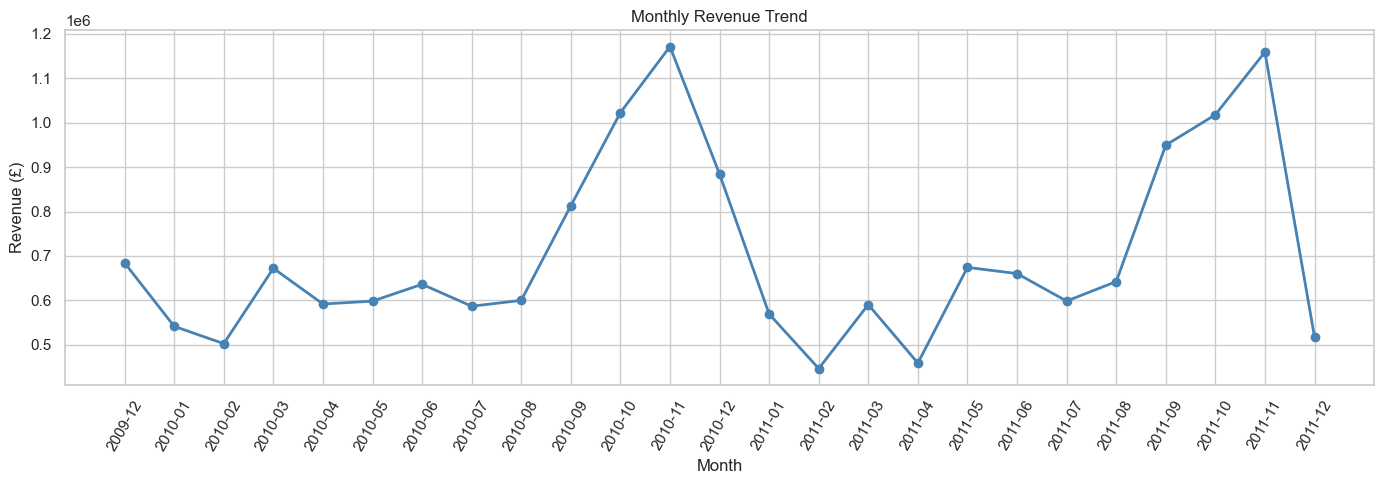

In [43]:
# Grouping revenue by month 
monthly_revenue = df_copy.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# Draw line chart that actually shows the change of revenue by passing months.
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'],
         monthly_revenue['TotalPrice'],
         marker='o',
         color='steelblue',
         linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()



In [44]:
# Growth from year 'Jan 2010 to Dec 2011' is -3.9% means the business is not growing even impacted negatively. 

yr2010 = df_copy[df_copy['Year'] == 2010]['TotalPrice'].sum()
yr2011 = df_copy[df_copy['Year'] == 2011]['TotalPrice'].sum()
growth = ((yr2011 - yr2010)/ yr2010)* 100

print(f"2010 Revenue : £{yr2010:,.2f}")

print(f"2011 Revenue : £{yr2011:,.2f}")

print(f"Growth : {growth:.1f}%")

2010 Revenue : £8,621,480.63
2011 Revenue : £8,285,160.25
Growth : -3.9%


/var/folders/vy/zdtjvtc135dgsm36hth1xnww0000gn/T/ipykernel_50967/3563451020.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_revenue.index,


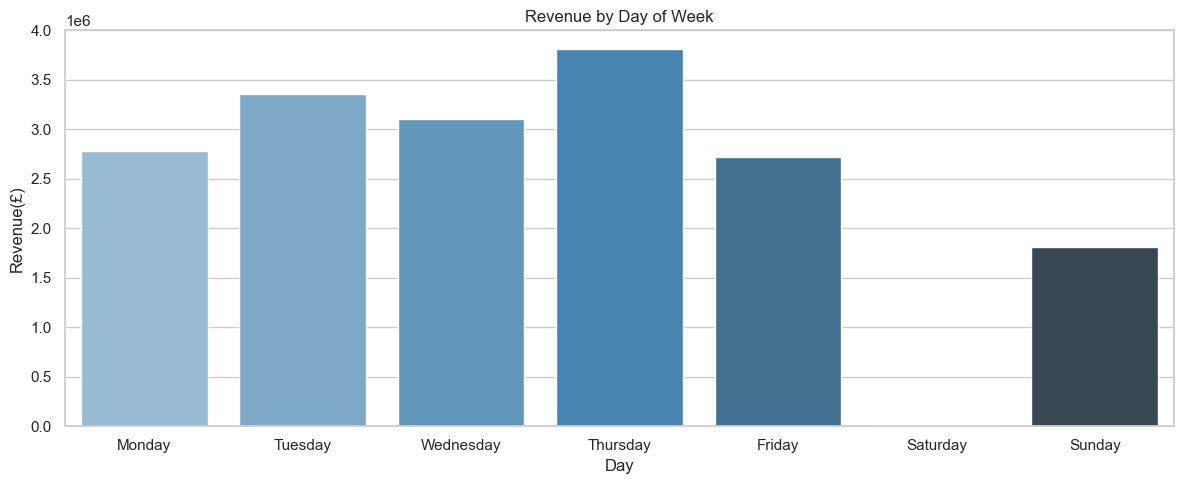

In [45]:
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group revenue by day of week
day_revenue = df_copy.groupby('DayOfWeek')['TotalPrice'].sum()
day_revenue = day_revenue.reindex(day_order)

# Draw bar chart
plt.figure(figsize=(12, 5))
sns.barplot(x=day_revenue.index,
            y=day_revenue.values,
            palette='Blues_d')
plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Revenue(£)')
plt.tight_layout()
plt.show()

In [46]:
#INSIGHT:
#95%+ orders happen on weekdays.
#This confirms B2B wholesale behaviour.
#Marketing campaigns should target
#Tuesday to Thursday during business hours.


peak_day    = day_revenue.idxmax()
weekend_rev = day_revenue[['Saturday', 'Sunday']].sum()
weekday_rev = day_revenue[['Monday', 'Tuesday',
                            'Wednesday', 'Thursday',
                            'Friday']].sum()
weekend_pct = weekend_rev / (weekend_rev + weekday_rev) * 100



print(f"Peak day         : {peak_day}")
print(f"Weekday revenue  : £{weekday_rev:,.2f}")
print(f"Weekend revenue  : £{weekend_rev:,.2f}")
print(f"Weekend share    : {weekend_pct:.1f}%")
print()



Peak day         : Thursday
Weekday revenue  : £15,766,344.16
Weekend revenue  : £1,824,744.45
Weekend share    : 10.4%



In [47]:
# Firstly identified the most common categories of products from 'Description' and listed them
# Then found the matching keywords for all categories 


category_keywords = {
    'Christmas'        : ['CHRISTMAS', 'XMAS', 'SANTA', 'REINDEER',
                          'SNOWMAN', 'WREATH', 'TINSEL', 'ADVENT',
                          'NOEL', 'SLEIGH'],
    'Bags'             : ['BAG', 'TOTE', 'SHOPPER', 'SATCHEL',
                          'PURSE', 'POUCH'],
    'Lighting'         : ['CANDLE', 'LIGHT', 'LANTERN', 'HOLDER',
                          'LAMP', 'TEA LIGHT'],
    'Kitchen'          : ['CAKE', 'KITCHEN', 'LUNCH', 'STORAGE', 'JAR',
                          'MUG', 'BOWL', 'TIN', 'BOTTLE', 'SNACK',
                          'JELLY', 'SAUCER', 'TEACUP', 'JAM', 'PANTRY',
                          'COOKIE CUTTER', 'GINGERBREAD', 'DOILIE',
                          'NAPKIN', 'PAPER PLATE', 'PAPER CUP', 'TEATIME',
                          'BREAD BIN', 'MEASURING JUG', 'CUTLERY',
                          'BREAKFAST SET', 'BREAKFAST PLATE', 'EGG CUP',
                          'TEA CADDY', 'TEA GLASS', 'ENAMEL'],
    'Party'            : ['PARTY', 'BUNTING', 'BALLOON', 'BANNER',
                          'DECORATION', 'GARLAND', 'PAPER CHAIN', 'BINGO'],
    'Home Decor'       : ['FRAME', 'SIGN', 'WALL', 'MIRROR', 'CLOCK',
                          'HANGING', 'PLAQUE', 'CABINET', 'DRAWER',
                          'DOORMAT', 'COAT RACK', 'BLOCK WORD',
                          'BLACKBOARD', 'CHALKBOARD', 'HOOK', 'HANGER',
                          'CHATEAU', 'LOVEBIRD', 'KEY FOB', 'WICKER',
                          'SLATE', 'DOOR MAT', 'BLOCK LETTERS',
                          'CIGAR BOX', 'ZINC', 'FOLKART'],
    'Gift and Wrap'    : ['CARD', 'WRAP', 'RIBBON', 'GIFT', 'TAG',
                          'BOW', 'TISSUE', 'NOTEBOOK', 'PARCEL'],
    'Vintage and Floral': ['HEART', 'ROSE', 'VINTAGE', 'RETRO', 'FLOWER',
                           'FLORAL', 'DAISY', 'PARASOL', 'EDWARDIAN',
                           'BUTTERFLY', 'SPOTTY', 'ANTIQUE'],
              'Toys'    : ['CHILDREN', 'KIDS', 'TOY', 'GAME', 'DOLL',
                          'BEAR', 'PUPPET', 'DOMINOES', 'HARMONICA',
                          'COLOURING', 'SKIPPING ROPE', 'SPINNING TOP',
                          'ROUNDERS', 'MODELLING CLAY', 'CRAYON',
                          'TRADITIONAL', 'SKITTLE', 'SOLDIER',
                          'PLAYHOUSE', 'CHILDS', 'SPACEBOY', 'CIRCUS'],
    'Home Textiles'    : ['CUSHION', 'BLANKET', 'THROW', 'PILLOW',
                          'TOWEL', 'BATH', 'KNEELING PAD'],
    'Ornaments'        : ['ORNAMENT', 'TRINKET', 'CERAMIC', 'FIGURINE',
                          'STATUE', 'STAR', 'BUTTERFLY'],
    'Craft and Stationery': ['CRAFT', 'FELT', 'WOOL', 'KNIT', 'SEW',
                              'SCHOOL', 'PENCIL', 'PAINT', 'COLOUR',
                              'CRAYON', 'STATIONERY', 'MATCHES'],
    'Garden'           : ['GARDEN', 'PLANT', 'LADDER', 'GARDENER',
                          'KNEELING', 'OUTDOOR', 'SHED',
                          'WATERING CAN'],
    'Accessories'      : ['HAND WARMER', 'UNION JACK', 'UNION FLAG',
                          'WARMER', 'GLOVE', 'SCARF'],
}

# Function which assigns category
def categorise(description):
    description = str(description).upper()
    for category, keywords in category_keywords.items():
        if any(keyword in description for keyword in keywords):
            return category
    return 'Other'

df_copy['Category'] = df_copy['Description'].apply(categorise)

# Check results
print(df_copy['Category'].value_counts())

Category
Kitchen                 182809
Home Decor              137006
Bags                     77176
Vintage and Floral       69547
Lighting                 69062
Other                    66492
Gift and Wrap            57453
Christmas                40521
Toys                     28868
Party                    28740
Craft and Stationery     20086
Ornaments                 9294
Home Textiles             8523
Garden                    5458
Accessories               3805
Name: count, dtype: int64


In [48]:
# This block oc code basically list all the product description which comed under the 'Others' category 
# By this i was able to extract more keywords to minimize the count of 'Others' Category 

other_products = df_copy[df_copy['Category'] == 'Other']['Description'].value_counts().head(25)
print(other_products)

Description
WOOD BLACK BOARD ANT WHITE FINISH      1075
BOX OF 6 MINI 50'S CRACKERS             381
SKULLS  WATER TRANSFER TATTOOS          378
BLACK/BLUE POLKADOT UMBRELLA            374
RED/WHITE DOTS RUFFLED UMBRELLA         374
POLYESTER FILLER PAD 40x40cm            372
SET OF 12 MINI LOAF BAKING CASES        370
GLASS  BEURRE DISH                      364
SLEEPING CAT ERASERS                    359
TOADSTOOL MONEY BOX                     358
HOLIDAY FUN LUDO                        354
HOME SMALL WOOD LETTERS                 353
POLYESTER FILLER PAD 45x45cm            347
CAMOUFLAGE LED TORCH                    346
SET OF 2 WOODEN MARKET CRATES           345
BROWN CHECK CAT DOORSTOP                341
BIG DOUGHNUT FRIDGE MAGNETS             339
UNION STRIPE WITH FRINGE  HAMMOCK       336
PHOTO CUBE                              336
WOOD STAMP SET THANK YOU                330
BUNDLE OF 3 ALPHABET EXERCISE BOOKS     324
SET OF 6 TEA TIME BAKING CASES          324
INFLATABLE POLITICAL

/var/folders/vy/zdtjvtc135dgsm36hth1xnww0000gn/T/ipykernel_50967/980701990.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.values,


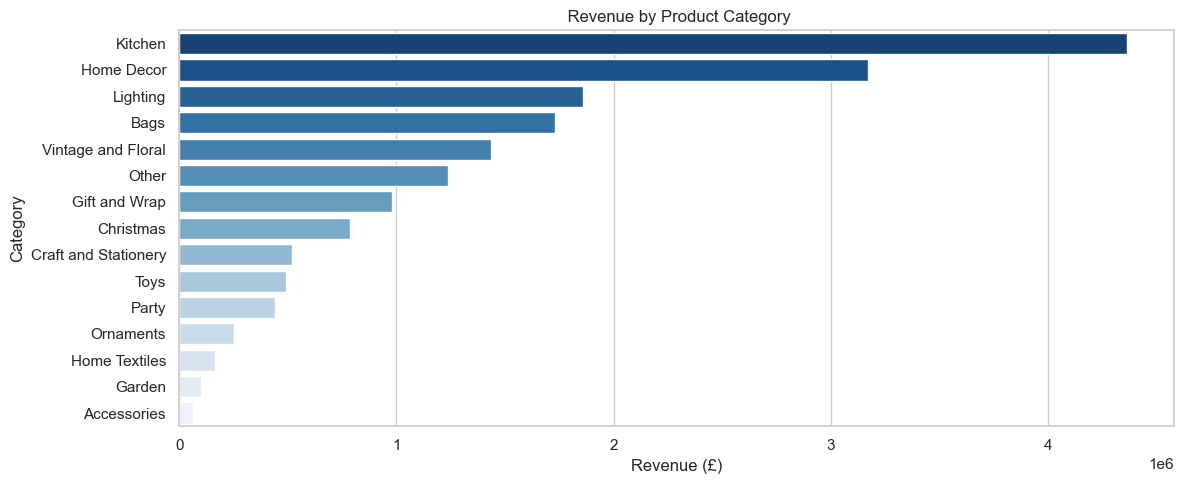

In [49]:

# Step 1 — Create category column from description


# Step 2 — Revenue by category
cat_revenue = df_copy.groupby('Category')['TotalPrice'].sum().sort_values(ascending=False)

# Step 3 — Draw a bar plot for this  chart
plt.figure(figsize=(12, 5))
sns.barplot(x=cat_revenue.values,
            y=cat_revenue.index,
            palette='Blues_r')
plt.title(' Revenue by Product Category')
plt.xlabel('Revenue (£)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()



In [50]:
top_cat = cat_revenue.index[0]
cat_revenue.iloc(0)
top_pct =  cat_revenue / cat_revenue.sum() * 100

for cat, rev in cat_revenue.items():
    pct = rev / cat_revenue.sum() * 100
    print(f"{cat:<22} : {pct:.1f}%")

Kitchen                : 24.8%
Home Decor             : 18.0%
Lighting               : 10.6%
Bags                   : 9.8%
Vintage and Floral     : 8.2%
Other                  : 7.0%
Gift and Wrap          : 5.6%
Christmas              : 4.5%
Craft and Stationery   : 3.0%
Toys                   : 2.8%
Party                  : 2.5%
Ornaments              : 1.4%
Home Textiles          : 0.9%
Garden                 : 0.6%
Accessories            : 0.4%


 FINDINGS 

  Top category    : Kitchen (24.8%)
  Top 3 combined  : Kitchen + Home Decor + Lightning = 53.4% 
  Business type   : Practical home products retailer
  Key insight     : Less seasonal than expected, People buy more household items which comes under daily usage 

In [51]:
# Grouping the Customer Id and Invoice to find the number of orders placed by each customer 

purchase_counts = df_copy.groupby('Customer_ID')['Invoice'].nunique()

# here sorted the number so that we will get top 15 customers with most orders
 
purchase_counts.sort_values(ascending= False).reset_index(name = 'Order_Count').head(15)

,Customer_ID,Order_Count
0,14911,379
1,12748,325
2,17841,211
3,15311,207
4,13089,203
5,14606,190
6,17850,155
7,14156,151
8,14646,151
9,18102,145


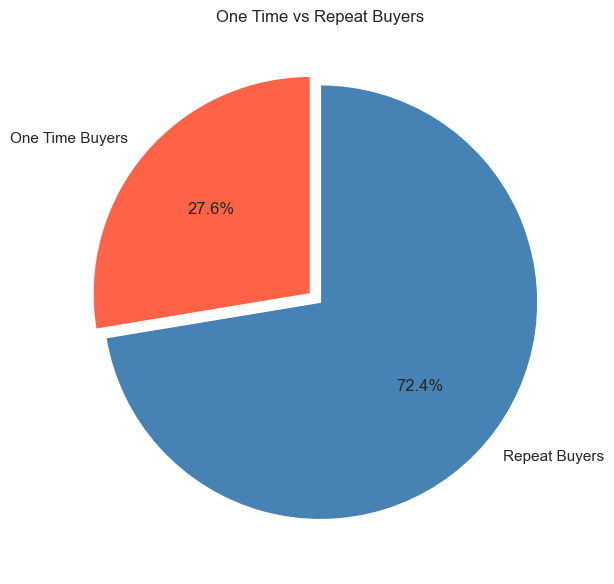

In [52]:
# Split into one time and repeat buyers
one_time = (purchase_counts == 1).sum()
repeat   = (purchase_counts > 1).sum()
total    = purchase_counts.count()

# Draw pie chart between Repeat Buyers and One Time Buyers

plt.figure(figsize=(8, 6))
plt.pie([one_time, repeat],
        labels=['One Time Buyers', 'Repeat Buyers'], colors=['tomato', 'steelblue'], autopct='%1.1f%%', startangle=90, explode=(0.06, 0))
plt.title('One Time vs Repeat Buyers')
plt.tight_layout()
plt.show()


In [53]:

# These lines will print the total customers, One time buyers and repeat buyers


print(f"Total customers   : {total:,}")
print(f"One time buyers   : {one_time:,} ({one_time/total*100:.1f}%)")
print(f"Repeat buyers     : {repeat:,} ({repeat/total*100:.1f}%)")



Total customers   : 5,863
One time buyers   : 1,619 (27.6%)
Repeat buyers     : 4,244 (72.4%)


INSIGHTS:

  27.6% of customers never came back 
  This finding will directly help in the RFM scoring 
